# Lab 5A — SI Demo: Predicting Student Exam Performance
**Module 5 Week A | Istidama Bootcamp**

---

## Scenario
A Jordanian university wants to identify at-risk students early in the semester.
We have data on **400 students** — demographics, study habits, attendance, and prior grades.

**Two prediction tasks:**
| Task | Type | Target |
|------|------|--------|
| Will the student pass? | Classification | `pass_fail` (0/1) |
| What will their final score be? | Regression | `final_score` (0–100) |

**Skills practiced (mirrors your telecom lab):**
- Train/test split with stratification
- `Pipeline` construction (scaler → model)
- Logistic Regression + classification metrics
- Ridge / Lasso regression + MAE & R²
- Stratified k-fold cross-validation
- Regularization: what changes when we add it?


---
## 0. Setup

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression, Ridge, Lasso, LinearRegression
from sklearn.metrics import (
    classification_report, accuracy_score,
    mean_absolute_error, r2_score
)

# Rich — formatted, colorized output
from rich.console import Console
from rich.table import Table
from rich.panel import Panel
from rich.text import Text
from rich import box

console = Console()

# Reproducibility
RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('muted')
pd.set_option('display.max_columns', 20)

console.print(Panel('[bold green]All imports successful.[/bold green]', title='Setup', border_style='green'))

╭───────────────────────────────────────────────────── Setup ─────────────────────────────────────────────────────╮
│ All imports successful.                                                                                         │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

---
## 1. Load & Explore the Dataset

In [27]:
df = pd.read_csv('students_performance.csv')
print(f'Shape: {df.shape}')
df.head()

Shape: (400, 15)


,student_id,age,gender,major,study_hours_per_week,attendance_pct,prior_gpa,num_courses,part_time_job,internet_access,family_support,distance_km,prev_failures,final_score,pass_fail
0,JU1000,18,F,Engineering,20.6,61.9,2.81,5,0,1,5,23.5,1,64.8,1
1,JU1001,24,F,Arts,18.8,51.3,2.69,5,0,1,4,3.5,0,69.8,1
2,JU1002,23,M,Science,13.3,76.4,2.97,4,1,1,4,1.0,2,70.1,1
3,JU1003,21,F,Engineering,18.8,64.0,2.79,4,1,1,5,7.4,0,69.0,1
4,JU1004,21,M,Arts,12.1,76.8,2.07,5,0,1,2,3.0,2,61.3,1


In [28]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   student_id            400 non-null    str    
 1   age                   400 non-null    int64  
 2   gender                400 non-null    str    
 3   major                 400 non-null    str    
 4   study_hours_per_week  400 non-null    float64
 5   attendance_pct        400 non-null    float64
 6   prior_gpa             400 non-null    float64
 7   num_courses           400 non-null    int64  
 8   part_time_job         400 non-null    int64  
 9   internet_access       400 non-null    int64  
 10  family_support        400 non-null    int64  
 11  distance_km           400 non-null    float64
 12  prev_failures         400 non-null    int64  
 13  final_score           400 non-null    float64
 14  pass_fail             400 non-null    int64  
dtypes: float64(5), int64(7), str(3)
me

In [29]:
df.describe().round(2)

,age,study_hours_per_week,attendance_pct,prior_gpa,num_courses,part_time_job,internet_access,family_support,distance_km,prev_failures,final_score,pass_fail
count,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00,400.00
mean,21.98,12.06,76.89,2.72,4.96,0.33,0.86,2.84,14.97,0.65,65.72,0.76
std,2.55,4.81,14.12,0.50,0.82,0.47,0.35,1.45,14.96,0.94,8.75,0.43
min,18.00,0.00,36.60,1.28,4.00,0.00,0.00,1.00,1.00,0.00,40.00,0.00
25%,20.00,9.17,67.62,2.40,4.00,0.00,1.00,1.00,3.90,0.00,60.48,1.00
50%,22.00,12.15,77.45,2.74,5.00,0.00,1.00,3.00,10.30,0.00,65.55,1.00
75%,24.00,15.02,87.12,3.05,6.00,1.00,1.00,4.00,20.32,1.00,72.22,1.00
max,26.00,27.90,100.00,4.00,6.00,1.00,1.00,5.00,80.00,3.00,100.00,1.00


In [30]:
# Check class balance — important before splitting!
pass_counts = df['pass_fail'].value_counts()

table = Table(title='Class Balance — Pass/Fail', box=box.ROUNDED, border_style='cyan')
table.add_column('Label', style='bold')
table.add_column('Class', justify='center')
table.add_column('Count', justify='right', style='bold yellow')
table.add_column('Rate', justify='right', style='bold green')

total = len(df)
for label, cls in [('Pass', 1), ('Fail', 0)]:
    count = pass_counts[cls]
    table.add_row(label, str(cls), str(count), f'{count/total:.1%}')

console.print(table)
console.print(f'  Overall pass rate: [bold green]{df["pass_fail"].mean():.1%}[/bold green]')

    Class Balance — Pass/Fail    
╭───────┬───────┬───────┬───────╮
│ Label │ Class │ Count │  Rate │
├───────┼───────┼───────┼───────┤
│ Pass  │   1   │   305 │ 76.2% │
│ Fail  │   0   │    95 │ 23.8% │
╰───────┴───────┴───────┴───────╯

Overall pass rate: 76.2%

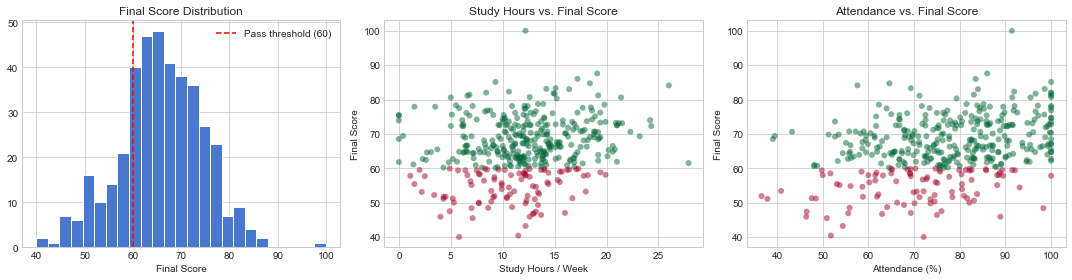

In [31]:
# Quick EDA: distribution of final scores by pass/fail
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Final score distribution
axes[0].hist(df['final_score'], bins=25, edgecolor='white')
axes[0].axvline(60, color='red', linestyle='--', label='Pass threshold (60)')
axes[0].set_title('Final Score Distribution')
axes[0].set_xlabel('Final Score')
axes[0].legend()

# Study hours vs. final score
axes[1].scatter(
    df['study_hours_per_week'], df['final_score'],
    c=df['pass_fail'], cmap='RdYlGn', alpha=0.5, edgecolors='none'
)
axes[1].set_xlabel('Study Hours / Week')
axes[1].set_ylabel('Final Score')
axes[1].set_title('Study Hours vs. Final Score')

# Attendance vs. final score
axes[2].scatter(
    df['attendance_pct'], df['final_score'],
    c=df['pass_fail'], cmap='RdYlGn', alpha=0.5, edgecolors='none'
)
axes[2].set_xlabel('Attendance (%)')
axes[2].set_ylabel('Final Score')
axes[2].set_title('Attendance vs. Final Score')

plt.tight_layout()
plt.show()

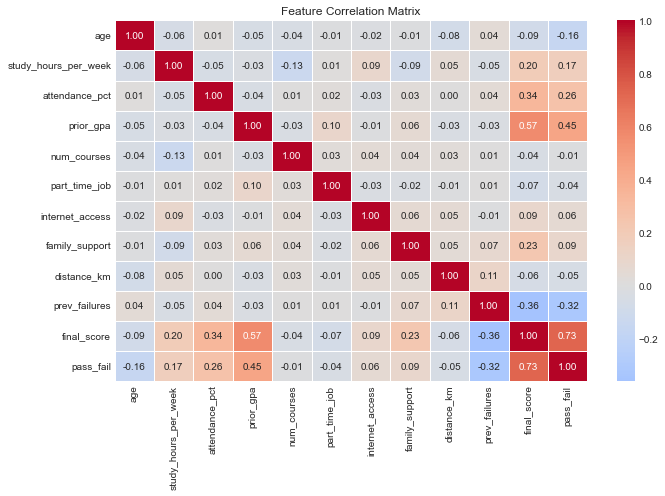

In [32]:
# Correlation heatmap (numeric features only)
numeric_cols = df.select_dtypes(include='number').drop(columns=['student_id'], errors='ignore')
plt.figure(figsize=(10, 7))
sns.heatmap(
    numeric_cols.corr(), annot=True, fmt='.2f',
    cmap='coolwarm', center=0, linewidths=0.5
)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

**EDA Takeaways:**
- `prior_gpa`, `study_hours_per_week`, and `attendance_pct` are the strongest predictors.
- `prev_failures` is negatively correlated with final score.
- The dataset is slightly imbalanced (~76% pass) — **stratification is important**.

---
## 2. Feature Engineering & Train/Test Split

> **Common mistake**: fitting the scaler on the *whole* dataset before splitting — this is **data leakage**. We use `Pipeline` to prevent it.

In [33]:
# Drop ID column; separate features from targets
df_model = df.drop(columns=['student_id'])

# Features: everything except the two targets
FEATURE_COLS = [c for c in df_model.columns if c not in ('final_score', 'pass_fail')]
print('Feature columns:\n' + '\n'.join(FEATURE_COLS))

X = df_model[FEATURE_COLS]
y_clf = df_model['pass_fail']     # classification target
y_reg = df_model['final_score']   # regression target

Feature columns:
age
gender
major
study_hours_per_week
attendance_pct
prior_gpa
num_courses
part_time_job
internet_access
family_support
distance_km
prev_failures


In [34]:
# Identify column types for the preprocessor
categorical_cols = X.select_dtypes(include='object').columns.tolist()
numeric_cols_feat = X.select_dtypes(include='number').columns.tolist()

print('Numeric features:\n' + '\n'.join(numeric_cols_feat))
print('\nCategorical features:\n' + '\n'.join(categorical_cols))

Numeric features:
age
study_hours_per_week
attendance_pct
prior_gpa
num_courses
part_time_job
internet_access
family_support
distance_km
prev_failures

Categorical features:
gender
major


/tmp/ipykernel_2138063/461362630.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include='object').columns.tolist()


In [35]:
# 80/20 split — STRATIFY on pass_fail to preserve class ratio
X_train, X_test, y_clf_train, y_clf_test, y_reg_train, y_reg_test = train_test_split(
    X, y_clf, y_reg,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_clf          # <-- preserves ~76% pass rate in both sets
)

table = Table(title='Train / Test Split', box=box.SIMPLE_HEAVY, border_style='blue')
table.add_column('Split', style='bold')
table.add_column('Size', justify='right', style='yellow')
table.add_column('Share', justify='right')
table.add_column('Pass Rate', justify='right', style='green')

table.add_row('Train', str(len(X_train)), f'{len(X_train)/len(X):.0%}', f'{y_clf_train.mean():.1%}')
table.add_row('Test',  str(len(X_test)),  f'{len(X_test)/len(X):.0%}',  f'{y_clf_test.mean():.1%}')

console.print(table)
console.print('[bold green]✓ Stratification preserved the class ratio.[/bold green]')

         Train / Test Split         
                                    
  Split   Size   Share   Pass Rate  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  Train    320     80%       76.2%  
  Test      80     20%       76.2%  
                                    

✓ Stratification preserved the class ratio.

In [36]:
# Shared preprocessor — fits ONLY on training data inside the Pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols_feat),
    ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols)
])
print('Preprocessor defined. It will be fit inside Pipeline.fit() — no leakage.')

Preprocessor defined. It will be fit inside Pipeline.fit() — no leakage.


---
## 3. Classification — Logistic Regression Pipeline

**Goal:** Predict `pass_fail` (0 = fail, 1 = pass).

In [37]:
# Build pipeline: preprocessing → LogisticRegression
clf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(max_iter=1000, random_state=RANDOM_STATE))
])

# Train
clf_pipeline.fit(X_train, y_clf_train)
print('Model trained.')

Model trained.


In [38]:
# Predict
y_clf_pred = clf_pipeline.predict(X_test)

print(f'Predictions shape : {y_clf_pred.shape}')
print('Unique values:')
print('\n'.join(str(v) for v in np.unique(y_clf_pred)))
print('\nFirst 10 preds:')
print('\n'.join(str(v) for v in y_clf_pred[:10]))

Predictions shape : (80,)
Unique values:
0
1

First 10 preds:
1
1
0
0
1
0
1
1
1
1


In [39]:
# Evaluate — classification metrics
y_clf_pred = clf_pipeline.predict(X_test)

report_str = classification_report(y_clf_test, y_clf_pred, target_names=['Fail', 'Pass'])
console.print(Panel(
    f'[white]{report_str}[/white]',
    title='[bold cyan]Classification Report — Logistic Regression[/bold cyan]',
    border_style='cyan',
    expand=False
))

╭───── Classification Report — Logistic Regression ─────╮
│               precision    recall  f1-score   support │
│                                                       │
│         Fail       0.72      0.68      0.70        19 │
│         Pass       0.90      0.92      0.91        61 │
│                                                       │
│     accuracy                           0.86        80 │
│    macro avg       0.81      0.80      0.81        80 │
│ weighted avg       0.86      0.86      0.86        80 │
│                                                       │
╰───────────────────────────────────────────────────────╯

In [40]:
# Structured metrics dictionary (mirrors what your lab autograder checks)
from sklearn.metrics import precision_score, recall_score, f1_score

classification_metrics = {
    'accuracy' : accuracy_score(y_clf_test, y_clf_pred),
    'precision': precision_score(y_clf_test, y_clf_pred),
    'recall'   : recall_score(y_clf_test, y_clf_pred),
    'f1'       : f1_score(y_clf_test, y_clf_pred),
}

table = Table(title='Classification Metrics', box=box.ROUNDED, border_style='magenta')
table.add_column('Metric', style='bold')
table.add_column('Value', justify='right', style='bold yellow')
table.add_column('Interpretation', style='dim')

interp = {
    'accuracy' : 'Overall correct predictions',
    'precision': 'Of predicted Pass, how many truly passed',
    'recall'   : 'Of actual Pass, how many we caught',
    'f1'       : 'Harmonic mean of precision & recall',
}
for k, v in classification_metrics.items():
    color = 'green' if v >= 0.85 else 'yellow' if v >= 0.70 else 'red'
    table.add_row(k.capitalize(), f'[{color}]{v:.4f}[/{color}]', interp[k])

console.print(table)

assert all(v > 0 for v in classification_metrics.values()), 'All metrics should be > 0'

                     Classification Metrics                      
╭───────────┬────────┬──────────────────────────────────────────╮
│ Metric    │  Value │ Interpretation                           │
├───────────┼────────┼──────────────────────────────────────────┤
│ Accuracy  │ 0.8625 │ Overall correct predictions              │
│ Precision │ 0.9032 │ Of predicted Pass, how many truly passed │
│ Recall    │ 0.9180 │ Of actual Pass, how many we caught       │
│ F1        │ 0.9106 │ Harmonic mean of precision & recall      │
╰───────────┴────────┴──────────────────────────────────────────╯

### 3.1 Interpreting the Classification Report

| Term | Meaning in our context |
|------|------------------------|
| **Precision** | Of all students we predicted would *pass*, what fraction actually passed? |
| **Recall** | Of all students who actually *failed*, what fraction did we catch? |
| **F1** | Harmonic mean of precision and recall — useful when classes are imbalanced |

> **University use case**: Recall on the *fail* class matters most — we'd rather flag too many at-risk students than miss them.

---
## 4. Regression — Ridge Pipeline

**Goal:** Predict the actual `final_score` (continuous, 40–100).

In [41]:
# Ridge regression pipeline
ridge_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_reg_train)

y_reg_pred_ridge = ridge_pipeline.predict(X_test)
print(f'Predictions — first 5: {y_reg_pred_ridge[:5].round(1)}')
print(f'True values — first 5: {y_reg_test.values[:5]}')

Predictions — first 5: [64.8 66.9 54.3 58.9 72. ]
True values — first 5: [66.3 62.1 53.1 59.5 74. ]


In [42]:
# Regression metrics
regression_metrics = {
    'mae': mean_absolute_error(y_reg_test, y_reg_pred_ridge),
    'r2' : r2_score(y_reg_test, y_reg_pred_ridge),
}

table = Table(title='Regression Metrics — Ridge', box=box.ROUNDED, border_style='blue')
table.add_column('Metric', style='bold')
table.add_column('Value', justify='right', style='bold yellow')
table.add_column('Interpretation', style='dim')

mae_color = 'green' if regression_metrics['mae'] < 5 else 'yellow'
r2_color  = 'green' if regression_metrics['r2'] > 0.7  else 'yellow' if regression_metrics['r2'] > 0.5 else 'red'

table.add_row('MAE', f'[{mae_color}]{regression_metrics["mae"]:.4f}[/{mae_color}]',
              'Mean abs. error in score points (lower is better)')
table.add_row('R²',  f'[{r2_color}]{regression_metrics["r2"]:.4f}[/{r2_color}]',
              'Variance explained — 1.0 is perfect (higher is better)')

console.print(table)

assert regression_metrics['r2'] > 0, 'R² should be positive — model beats a flat mean prediction'

                         Regression Metrics — Ridge                         
╭────────┬────────┬────────────────────────────────────────────────────────╮
│ Metric │  Value │ Interpretation                                         │
├────────┼────────┼────────────────────────────────────────────────────────┤
│ MAE    │ 3.6701 │ Mean abs. error in score points (lower is better)      │
│ R²     │ 0.7412 │ Variance explained — 1.0 is perfect (higher is better) │
╰────────┴────────┴────────────────────────────────────────────────────────╯

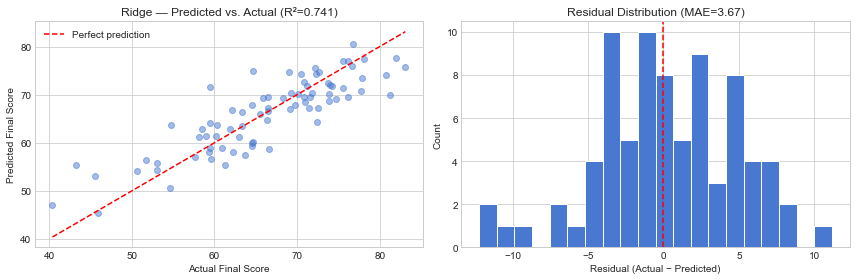

In [43]:
# Visualise predictions vs. actuals
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Scatter: predicted vs. actual
axes[0].scatter(y_reg_test, y_reg_pred_ridge, alpha=0.5)
lims = [y_reg_test.min(), y_reg_test.max()]
axes[0].plot(lims, lims, 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual Final Score')
axes[0].set_ylabel('Predicted Final Score')
axes[0].set_title(f'Ridge — Predicted vs. Actual (R²={regression_metrics["r2"]:.3f})')
axes[0].legend()

# Residuals
residuals = y_reg_test.values - y_reg_pred_ridge
axes[1].hist(residuals, bins=20, edgecolor='white')
axes[1].axvline(0, color='red', linestyle='--')
axes[1].set_xlabel('Residual (Actual − Predicted)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Residual Distribution (MAE={regression_metrics["mae"]:.2f})')

plt.tight_layout()
plt.show()

---
## 5. Regularization Deep-Dive — OLS vs. Ridge vs. Lasso

Regularization adds a **penalty term** to shrink large coefficients.

| Model | Penalty | Effect |
|-------|---------|--------|
| `LinearRegression` | None | Coefficients can be large/noisy |
| `Ridge` | L2 (sum of squared coefs) | Shrinks all coefs toward zero; keeps all features |
| `Lasso` | L1 (sum of absolute coefs) | Drives some coefs **exactly to zero** — automatic feature selection |

> **Note:** In `LogisticRegression`, the regularization parameter is **`C`** (inverse strength — smaller = more regularization). In `Ridge`/`Lasso`, it is **`alpha`** (direct strength — larger = more regularization).

In [44]:
def make_reg_pipeline(model):
    return Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('regressor', model)
    ])

models = {
    'OLS (no regularization)': LinearRegression(),
    'Ridge (alpha=1)':         Ridge(alpha=1.0),
    'Ridge (alpha=10)':        Ridge(alpha=10.0),
    'Lasso (alpha=1)':         Lasso(alpha=1.0, max_iter=5000),
    'Lasso (alpha=5)':         Lasso(alpha=5.0, max_iter=5000),
}

results = []
coef_store = {}

for name, model in models.items():
    pipe = make_reg_pipeline(model)
    pipe.fit(X_train, y_reg_train)
    preds = pipe.predict(X_test)
    results.append({
        'Model': name,
        'MAE':   round(mean_absolute_error(y_reg_test, preds), 3),
        'R²':    round(r2_score(y_reg_test, preds), 3),
    })
    coef_store[name] = pipe.named_steps['regressor'].coef_

results_df = pd.DataFrame(results)

table = Table(title='Regularization Comparison', box=box.DOUBLE_EDGE, border_style='magenta')
table.add_column('Model', style='bold')
table.add_column('MAE', justify='right')
table.add_column('R²',  justify='right')

best_r2 = max(r['R²'] for r in results)
for r in results:
    mae_color = 'green' if r['MAE'] < 4.0 else 'yellow' if r['MAE'] < 6.0 else 'red'
    r2_color  = 'green' if r['R²'] == best_r2 else 'yellow' if r['R²'] > 0.5 else 'red'
    star = ' ★' if r['R²'] == best_r2 else ''
    table.add_row(
        r['Model'] + star,
        f'[{mae_color}]{r["MAE"]}[/{mae_color}]',
        f'[{r2_color}]{r["R²"]}[/{r2_color}]',
    )

console.print(table)

          Regularization Comparison           
╔═══════════════════════════╤═══════╤════════╗
║ Model                     │   MAE │     R² ║
╟───────────────────────────┼───────┼────────╢
║ OLS (no regularization) ★ │ 3.674 │  0.741 ║
║ Ridge (alpha=1) ★         │  3.67 │  0.741 ║
║ Ridge (alpha=10)          │ 3.657 │  0.738 ║
║ Lasso (alpha=1)           │ 4.331 │   0.62 ║
║ Lasso (alpha=5)           │  7.35 │ -0.006 ║
╚═══════════════════════════╧═══════╧════════╝

In [45]:
# Get feature names after one-hot encoding
# Fit the preprocessor temporarily to get feature names
_pp = preprocessor
_pp.fit(X_train)
num_feature_names = numeric_cols_feat
cat_feature_names = _pp.named_transformers_['cat'].get_feature_names_out(categorical_cols).tolist()
all_feature_names = num_feature_names + cat_feature_names

print(f'Total features after encoding: {len(all_feature_names)}')
print('\n'.join(all_feature_names))

Total features after encoding: 14
age
study_hours_per_week
attendance_pct
prior_gpa
num_courses
part_time_job
internet_access
family_support
distance_km
prev_failures
gender_M
major_Business
major_Engineering
major_Science


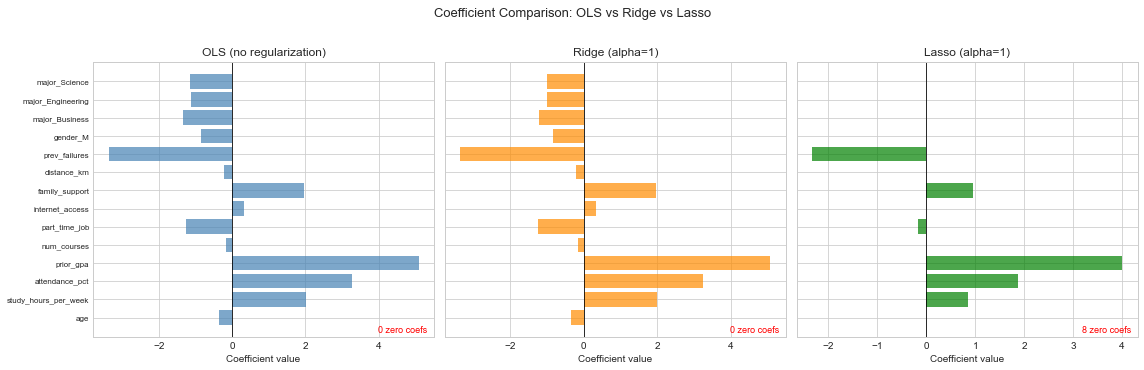


Lasso zero coefficients (eliminated features):
  age → 0
  num_courses → 0
  internet_access → 0
  distance_km → 0
  gender_M → 0
  major_Business → 0
  major_Engineering → 0
  major_Science → 0


In [46]:
# Coefficient comparison: OLS vs Lasso (shows zeroing effect)
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)
plot_models = ['OLS (no regularization)', 'Ridge (alpha=1)', 'Lasso (alpha=1)']
colors = ['steelblue', 'darkorange', 'green']

for ax, model_name, color in zip(axes, plot_models, colors):
    coefs = coef_store[model_name]
    y_pos = np.arange(len(coefs))
    ax.barh(y_pos, coefs, color=color, alpha=0.7)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(all_feature_names, fontsize=8)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(model_name)
    ax.set_xlabel('Coefficient value')
    
    # Annotate zeros (Lasso)
    n_zero = np.sum(np.abs(coefs) < 1e-4)
    ax.text(0.98, 0.02, f'{n_zero} zero coefs', transform=ax.transAxes,
            ha='right', fontsize=9, color='red')

plt.suptitle('Coefficient Comparison: OLS vs Ridge vs Lasso', y=1.02, fontsize=13)
plt.tight_layout()
plt.show()

print()
print('Lasso zero coefficients (eliminated features):')
lasso_coefs = coef_store['Lasso (alpha=1)']
for name, coef in zip(all_feature_names, lasso_coefs):
    if abs(coef) < 1e-4:
        print(f'  {name} → 0')

**Key observation:** Lasso drives several coefficients to exactly zero, effectively removing those features from the model. This is automatic feature selection — useful when you have many features and want interpretability.

---
## 6. Cross-Validation — Stratified 5-Fold

A single train/test split can give a lucky or unlucky result.
**Cross-validation** gives us a more reliable estimate of model performance.

For classification with imbalanced classes, use **`StratifiedKFold`** to ensure each fold has the same class proportion.

In [47]:
# 5-fold stratified CV on the classification pipeline
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_scores = cross_val_score(
    clf_pipeline,
    X, y_clf,
    cv=skf,
    scoring='f1'
)

table = Table(title='5-Fold Stratified CV — Logistic Regression (F1)', box=box.ROUNDED, border_style='cyan')
table.add_column('Fold', justify='center', style='bold')
table.add_column('F1 Score', justify='right', style='yellow')

for i, score in enumerate(cv_scores, 1):
    bar = '█' * int(score * 20)
    table.add_row(f'Fold {i}', f'{score:.3f}  {bar}')

table.add_section()
table.add_row('[bold]Mean[/bold]',   f'[bold green]{cv_scores.mean():.3f}[/bold green]')
table.add_row('[bold]Std[/bold]',    f'[bold]{cv_scores.std():.3f}[/bold]')
table.add_row('[bold]95% CI[/bold]', f'[bold]{cv_scores.mean():.3f} ± {2*cv_scores.std():.3f}[/bold]')

console.print(table)

assert len(cv_scores) == 5, 'Expected 5 folds'
assert cv_scores.mean() > 0.5, 'Mean CV score should exceed 0.5'

   5-Fold Stratified CV — Logistic    
           Regression (F1)            
╭────────┬───────────────────────────╮
│  Fold  │                  F1 Score │
├────────┼───────────────────────────┤
│ Fold 1 │  0.882  █████████████████ │
│ Fold 2 │ 0.931  ██████████████████ │
│ Fold 3 │  0.881  █████████████████ │
│ Fold 4 │ 0.923  ██████████████████ │
│ Fold 5 │ 0.919  ██████████████████ │
├────────┼───────────────────────────┤
│  Mean  │                     0.907 │
│  Std   │                     0.021 │
│ 95% CI │             0.907 ± 0.043 │
╰────────┴───────────────────────────╯

In [48]:
# Compare CV across multiple classifiers
from sklearn.linear_model import LogisticRegression

clf_variants = {
    'LogReg (default C=1)' : LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
    'LogReg (C=0.1)'       : LogisticRegression(C=0.1, max_iter=1000, random_state=RANDOM_STATE),
    'LogReg (C=10)'        : LogisticRegression(C=10, max_iter=1000, random_state=RANDOM_STATE),
}

cv_results = []
for name, clf in clf_variants.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('classifier', clf)])
    scores = cross_val_score(pipe, X, y_clf, cv=skf, scoring='f1')
    cv_results.append({'Model': name, 'Mean F1': scores.mean(), 'Std': scores.std()})

best_mean = max(r['Mean F1'] for r in cv_results)

table = Table(title='Regularization (C) — CV F1 Comparison', box=box.SIMPLE_HEAVY, border_style='blue')
table.add_column('Model', style='bold')
table.add_column('Mean F1', justify='right')
table.add_column('Std',     justify='right', style='dim')

for r in cv_results:
    color = 'green' if r['Mean F1'] == best_mean else 'white'
    star  = ' ★' if r['Mean F1'] == best_mean else ''
    table.add_row(
        r['Model'] + star,
        f'[{color}]{r["Mean F1"]:.3f}[/{color}]',
        f'{r["Std"]:.3f}',
    )

console.print(table)

  Regularization (C) — CV F1 Comparison   
                                          
  Model                  Mean F1     Std  
 ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 
  LogReg (default C=1)     0.907   0.021  
  LogReg (C=0.1) ★         0.917   0.020  
  LogReg (C=10)            0.907   0.018  
                                          

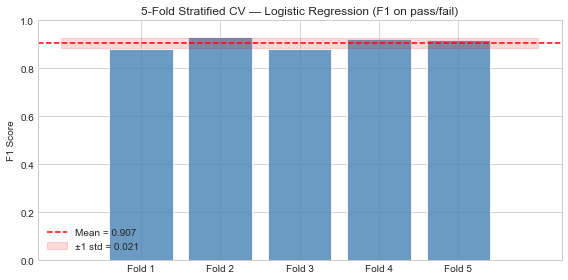


Low std (0.021) → model is stable across different subsets of data.


In [49]:
# Visualise CV score variance
plt.figure(figsize=(8, 4))
fold_labels = [f'Fold {i+1}' for i in range(5)]
bars = plt.bar(fold_labels, cv_scores, color='steelblue', alpha=0.8, edgecolor='white')
plt.axhline(cv_scores.mean(), color='red', linestyle='--', label=f'Mean = {cv_scores.mean():.3f}')
plt.fill_between(
    range(-1, 6),
    cv_scores.mean() - cv_scores.std(),
    cv_scores.mean() + cv_scores.std(),
    alpha=0.15, color='red', label=f'±1 std = {cv_scores.std():.3f}'
)
plt.ylim(0, 1)
plt.ylabel('F1 Score')
plt.title('5-Fold Stratified CV — Logistic Regression (F1 on pass/fail)')
plt.legend()
plt.tight_layout()
plt.show()

print(f'\nLow std ({cv_scores.std():.3f}) → model is stable across different subsets of data.')

---
## 7. Final Summary & University Recommendation

In [50]:
# ── Classification summary ──────────────────────────────────────────────────
clf_table = Table(title='Classification — Pass/Fail', box=box.MINIMAL_DOUBLE_HEAD, border_style='cyan')
clf_table.add_column('Metric',    style='bold')
clf_table.add_column('Value',     justify='right', style='bold yellow')

for k, v in classification_metrics.items():
    clf_table.add_row(k.capitalize(), f'{v:.3f}')

# ── Regression summary ───────────────────────────────────────────────────────
reg_table = Table(title='Regression — Final Score (Ridge)', box=box.MINIMAL_DOUBLE_HEAD, border_style='blue')
reg_table.add_column('Metric', style='bold')
reg_table.add_column('Value',  justify='right', style='bold yellow')

reg_table.add_row('MAE', f'{regression_metrics["mae"]:.3f}')
reg_table.add_row('R²',  f'{regression_metrics["r2"]:.3f}')

# ── CV summary ───────────────────────────────────────────────────────────────
cv_table = Table(title='Cross-Validation — 5-Fold Stratified F1', box=box.MINIMAL_DOUBLE_HEAD, border_style='green')
cv_table.add_column('Stat',  style='bold')
cv_table.add_column('Value', justify='right', style='bold yellow')

cv_table.add_row('Mean F1', f'{cv_scores.mean():.3f}')
cv_table.add_row('Std',     f'{cv_scores.std():.3f}')

console.print()
console.print(clf_table)
console.print(reg_table)
console.print(cv_table)

# ── Recommendations ──────────────────────────────────────────────────────────
top_features = ['prior_gpa', 'study_hours_per_week', 'attendance_pct', 'prev_failures']
rec_text = (
    f'[bold yellow]Top predictors of failure:[/bold yellow] {", ".join(top_features)}\n\n'
    f'[cyan]1.[/cyan] Flag students with [bold]attendance < 65%[/bold] AND [bold]prior GPA < 2.5[/bold] early.\n'
    f'[cyan]2.[/cyan] Offer tutoring to students with [bold]prev_failures > 0[/bold].\n'
    f'[cyan]3.[/cyan] The model identifies [bold green]~{classification_metrics["recall"]:.0%}[/bold green] of at-risk students (recall).\n'
    f'[cyan]4.[/cyan] Low CV std suggests the model [bold green]generalises well[/bold green] — safe to deploy.'
)

console.print(Panel(rec_text, title='[bold]University Recommendation[/bold]', border_style='green', expand=False))

  Classification —   
      Pass/Fail      
            ╷        
  Metric    │ Value  
 ═══════════╪═══════ 
  Accuracy  │ 0.863  
  Precision │ 0.903  
  Recall    │ 0.918  
  F1        │ 0.911  
            ╵        

Regression — Final
  Score (Ridge)   
         ╷        
  Metric │ Value  
 ════════╪═══════ 
  MAE    │ 3.670  
  R²     │ 0.741  
         ╵        

Cross-Validation — 
 5-Fold Stratified 
        F1         
          ╷        
  Stat    │ Value  
 ═════════╪═══════ 
  Mean F1 │ 0.907  
  Std     │ 0.021  
          ╵        

╭──────────────────────────────── University Recommendation ────────────────────────────────╮
│ Top predictors of failure: prior_gpa, study_hours_per_week, attendance_pct, prev_failures │
│                                                                                           │
│ 1. Flag students with attendance < 65% AND prior GPA < 2.5 early.                         │
│ 2. Offer tutoring to students with prev_failures > 0.                                     │
│ 3. The model identifies ~92% of at-risk students (recall).                                │
│ 4. Low CV std suggests the model generalises well — safe to deploy.                       │
╰───────────────────────────────────────────────────────────────────────────────────────────╯